# Exploratory GMM Clustering Notebook

This notebook mirrors the src pipeline but adds an exploratory switch to force a fixed number of clusters.

Use the settings cell to temporarily hardcode `k=3` (or another value) and regenerate `cluster_phase_heatmap.png`.

In [35]:
from pathlib import Path
import sys
import json

# Resolve repository root and ensure src is importable from this notebook.
cwd = Path.cwd()
if (cwd / "src").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "src").exists():
    REPO_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not locate repository root containing src/")

src_path = str(REPO_ROOT / "src")
if src_path not in sys.path:
    sys.path.append(src_path)

from physio_pipeline.config import PipelineConfig
from physio_pipeline.data_io import ensure_output_directories, load_dataset
from physio_pipeline.preprocessing import preprocess_dataset
from physio_pipeline.pca_stage import run_pca
from physio_pipeline.model_selection import evaluate_gmm_candidates
from physio_pipeline.clustering import fit_final_gmm
from physio_pipeline.evaluation import evaluate_phase_alignment
from physio_pipeline.visualization import (
    plot_cumulative_variance,
    plot_aic_bic,
    plot_cluster_phase_heatmap,
)

REPO_ROOT

PosixPath('/Users/jiji/Documents/02582_Computational_Data_Analysis/case_II/02582_CDA_Case2')

In [47]:
from pathlib import Path

DATA_PATH = REPO_ROOT.parent / "data" / "HR_data_2.csv"
OUTPUT_DIR = REPO_ROOT / "outputs_jawhara_exploratory_gmm"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "results").mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("Exists?   ", DATA_PATH.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)
print("Exists before run:", OUTPUT_DIR.exists())

DATA_PATH: /Users/jiji/Documents/02582_Computational_Data_Analysis/case_II/data/HR_data_2.csv
Exists?    True
OUTPUT_DIR: /Users/jiji/Documents/02582_Computational_Data_Analysis/case_II/02582_CDA_Case2/outputs_jawhara_exploratory_gmm
Exists before run: True


## Exploration Settings

Change values in this cell to explore different clustering assumptions.

- Set `USE_FIXED_K = True` and `FIXED_K = 3` to hardcode three clusters.
- Set `USE_FIXED_K = False` to use BIC-selected k.

In [48]:
PCA_VARIANCE_THRESHOLD = 0.80
K_MIN = 1
K_MAX = 8
RANDOM_STATE = 42
GMM_N_INIT = 10
GMM_COVARIANCE_TYPE = "diag"

# Exploratory switch: set True to hardcode k, False to use BIC minimum.
USE_FIXED_K = True
FIXED_K = 3

config = PipelineConfig(
    data_path=DATA_PATH,
    output_dir=OUTPUT_DIR,
    pca_variance_threshold=PCA_VARIANCE_THRESHOLD,
    gmm_k_min=K_MIN,
    gmm_k_max=K_MAX,
    random_state=RANDOM_STATE,
    gmm_n_init=GMM_N_INIT,
    gmm_covariance_type=GMM_COVARIANCE_TYPE,
)

if USE_FIXED_K and not (K_MIN <= FIXED_K <= K_MAX):
    raise ValueError(f"FIXED_K must be in [{K_MIN}, {K_MAX}]")

config

PipelineConfig(data_path=PosixPath('/Users/jiji/Documents/02582_Computational_Data_Analysis/case_II/data/HR_data_2.csv'), output_dir=PosixPath('/Users/jiji/Documents/02582_Computational_Data_Analysis/case_II/02582_CDA_Case2/outputs_jawhara_exploratory_gmm'), random_state=42, pca_variance_threshold=0.8, group_column='Individual', phase_column='Phase', required_columns=('Individual', 'Phase', 'Round'), physiological_prefixes=('HR_', 'EDA_', 'TEMP_'), run_gmm=True, gmm_k_min=1, gmm_k_max=8, gmm_n_init=10, gmm_covariance_type='diag', gmm_cluster_column='GMMCluster', run_kmeans=True, kmeans_k_min=2, kmeans_k_max=8, kmeans_n_init=50, kmeans_final_k=None, kmeans_cluster_column='KMeansCluster')

In [49]:
# 1) Data loading and preprocessing
figures_dir, results_dir = ensure_output_directories(config.output_dir)
raw_df = load_dataset(config.data_path, config.required_columns)

prep = preprocess_dataset(
    df=raw_df,
    prefixes=config.physiological_prefixes,
    group_column=config.group_column,
)

feature_matrix = prep.processed_df[prep.feature_columns].to_numpy()
prep.missingness_report.to_csv(results_dir / "missingness_report.csv", index=False)

print(f"Rows: {len(raw_df)}")
print(f"Physiological feature count: {len(prep.feature_columns)}")
print(f"Imputation method used: {prep.imputation_method}")
print(f"Global missingness ratio: {prep.global_missingness_ratio:.6f}")

Rows: 312
Physiological feature count: 51
Imputation method used: median
Global missingness ratio: 0.000126


#### PCA
In our analysis, PCA is used as an exploratory representation step before clustering. It reduces the physiological feature space to a smaller set of principal components that capture the dominant variation in the data, after which we investigate whether the resulting latent structure aligns with the experimental phases.

In [50]:
# 2) PCA diagnostics and transformation
pca_result = run_pca(
    feature_matrix=feature_matrix,
    variance_threshold=config.pca_variance_threshold,
    random_state=config.random_state,
)

pca_result.variance_table.to_csv(results_dir / "pca_variance_table.csv", index=False)
plot_cumulative_variance(
    variance_table=pca_result.variance_table,
    variance_threshold=config.pca_variance_threshold,
    output_path=figures_dir / "pca_cumulative_explained_variance.png",
)

print(f"Selected PCA components (>= {config.pca_variance_threshold:.0%} variance): {pca_result.selected_components}")
pca_result.variance_table.head(10)

Selected PCA components (>= 80% variance): 14


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.202623,0.202623
1,2,0.090646,0.293268
2,3,0.081332,0.374600
3,4,0.073221,0.447821
4,5,0.066036,0.513857
5,6,0.054504,0.568361
6,7,0.051223,0.619584
7,8,0.034922,0.654506
8,9,0.030937,0.685443
9,10,0.029549,0.714991


 In our case, PCA is used to compress 51 correlated physiological features into a smaller set of principal components. This reflects the idea that the wearable features are partly redundant and that the main physiological variation may lie in a lower-dimensional latent space. Clustering is then performed on these PCA scores rather than on the raw features.

The main structure of the data can be summarized with around 14–20 combined directions:
- with the 0.8 threshold, you kept about 14 PCs
- with the 0.9 threshold, you kept about 20 PCs. 



In [51]:
# 3) GMM model selection with AIC/BIC for k=1..8
selection = evaluate_gmm_candidates(
    feature_matrix=pca_result.transformed,
    k_min=config.gmm_k_min,
    k_max=config.gmm_k_max,
    random_state=config.random_state,
    n_init=config.gmm_n_init,
    covariance_type=config.gmm_covariance_type,
)

selection.scores.to_csv(results_dir / "gmm_aic_bic_scores.csv", index=False)
plot_aic_bic(selection.scores, figures_dir / "gmm_aic_bic_by_k.png")

bic_selected_k = int(selection.optimal_k)
print(f"BIC-selected k: {bic_selected_k}")
selection.scores

BIC-selected k: 2


,k,aic,bic,log_likelihood
0,1,16228.122353,16332.926443,-25.916863
1,2,16080.685753,16294.036935,-25.587637
2,3,16055.164125,16377.062399,-25.453789
3,4,15882.558340,16313.003706,-25.084228
4,5,16029.400846,16568.393305,-25.226604
5,6,16008.497982,16656.037533,-25.100157
6,7,16012.179551,16768.266195,-25.013108
7,8,16004.528662,16869.162399,-24.907898


In [53]:
# 4) Final clustering with optional fixed-k override
if USE_FIXED_K:
    final_k = int(FIXED_K)
    print(f"Using fixed exploratory k={final_k}")
else:
    final_k = bic_selected_k
    print(f"Using BIC-selected k={final_k}")

_, labels = fit_final_gmm(
    feature_matrix=pca_result.transformed,
    n_components=final_k,
    random_state=config.random_state,
    n_init=config.gmm_n_init,
    covariance_type=config.gmm_covariance_type,
)

enriched_df = raw_df.copy()
enriched_df[config.gmm_cluster_column] = labels

evaluation = evaluate_phase_alignment(
    df=enriched_df,
    cluster_column=config.gmm_cluster_column,
    phase_column=config.phase_column,
)



suffix = f"_k{final_k}"

heatmap_path = figures_dir / f"cluster_phase_heatmap{suffix}.png"
plot_cluster_phase_heatmap(evaluation.normalized_table, heatmap_path)

enriched_df.to_csv(results_dir / f"hr_data_with_clusters{suffix}.csv", index=False)
evaluation.counts_table.to_csv(results_dir / f"cluster_phase_counts{suffix}.csv")
evaluation.normalized_table.to_csv(results_dir / f"cluster_phase_normalized{suffix}.csv")

with (results_dir / f"mapped_classification_report{suffix}.txt").open("w", encoding="utf-8") as file:
    file.write(evaluation.mapped_report)

with (results_dir / f"cluster_to_phase_mapping{suffix}.json").open("w", encoding="utf-8") as file:
    json.dump(evaluation.cluster_to_phase_map, file, indent=2)

selected_row = selection.scores[selection.scores["k"] == final_k].iloc[0]
summary = {
    "use_fixed_k": bool(USE_FIXED_K),
    "fixed_k": int(FIXED_K) if USE_FIXED_K else None,
    "bic_selected_k": int(bic_selected_k),
    "final_k_used": int(final_k),
    "selected_k_aic": float(selected_row["aic"]),
    "selected_k_bic": float(selected_row["bic"]),
    "nmi": float(evaluation.nmi),
    "selected_pca_components": int(pca_result.selected_components),
    "global_missingness_ratio": float(prep.global_missingness_ratio),
}

with (results_dir / f"metrics_summary{suffix}.json").open("w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2)

print(f"Saved exploratory heatmap to: {heatmap_path}")
print(f"NMI (Phase vs Cluster): {evaluation.nmi:.4f}")
print("Saved exploratory outputs with suffix:", suffix)
evaluation.normalized_table

Using fixed exploratory k=3
Saved exploratory heatmap to: /Users/jiji/Documents/02582_Computational_Data_Analysis/case_II/02582_CDA_Case2/outputs_jawhara_exploratory_gmm/figures/cluster_phase_heatmap_k3.png
NMI (Phase vs Cluster): 0.0209
Saved exploratory outputs with suffix: _k3


Phase,phase1,phase2,phase3
GMMCluster,,,
0,0.468354,0.253165,0.278481
1,0.355932,0.313559,0.330508
2,0.217391,0.408696,0.373913


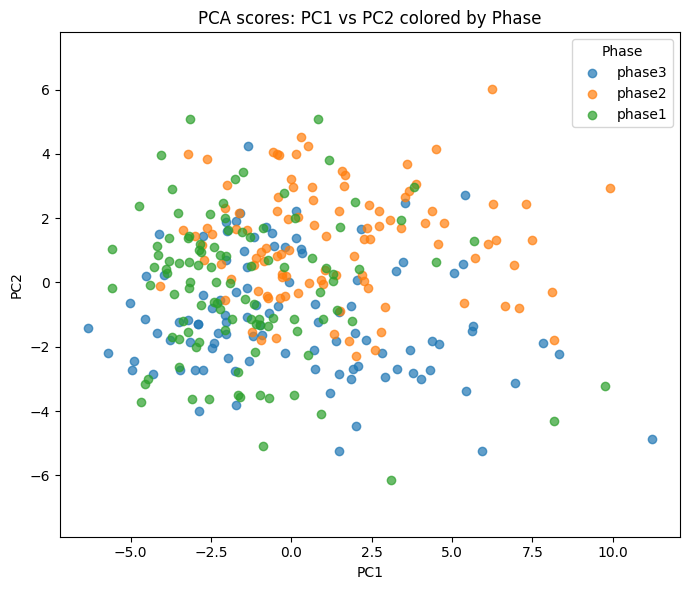

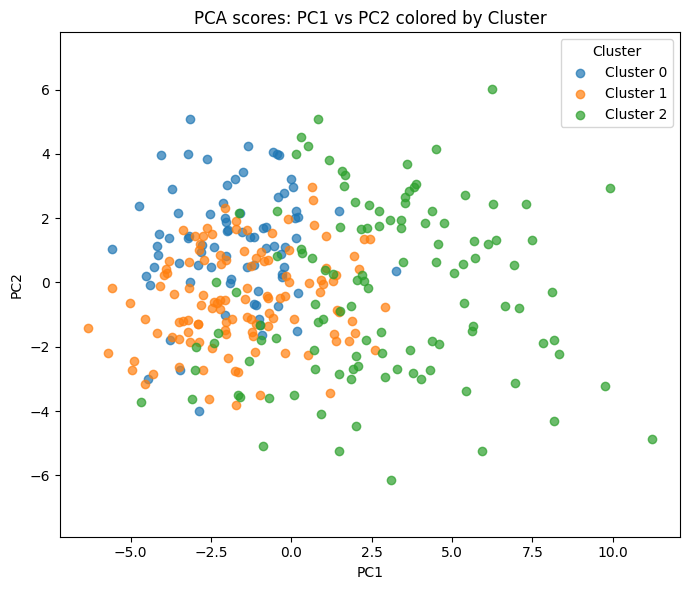

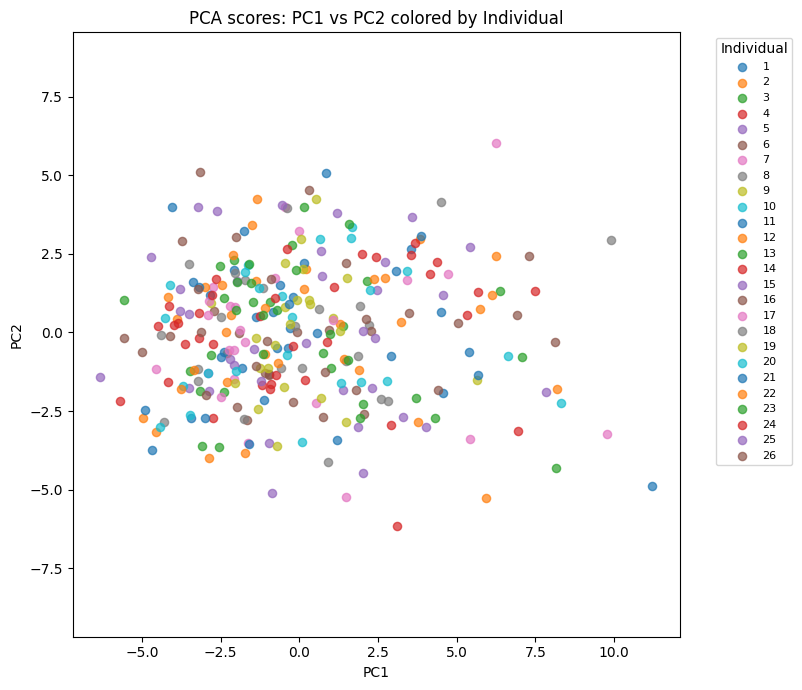

In [54]:
CLUSTER_COLUMN = "GMMCluster"

# =========================
# PCA diagnostics and interpretation plots
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Refit PCA directly so we can access scores + loadings clearly
X = prep.processed_df[prep.feature_columns].to_numpy()
feature_names = prep.feature_columns

pca_full = PCA(random_state=config.random_state)
scores_full = pca_full.fit_transform(X)

explained_var = pca_full.explained_variance_ratio_
cumvar = np.cumsum(explained_var)
eigenvalues = pca_full.explained_variance_

n_components_selected = int(np.searchsorted(cumvar, config.pca_variance_threshold) + 1)

scores_df = pd.DataFrame({
    "PC1": scores_full[:, 0],
    "PC2": scores_full[:, 1],
    "Phase": raw_df[config.phase_column].values,
    "Individual": raw_df[config.group_column].values,
    "Cluster": enriched_df[CLUSTER_COLUMN].values,
})

# -------------------------
# 1) PC1 vs PC2 colored by Phase
# -------------------------
plt.figure(figsize=(7, 6))
for phase in scores_df["Phase"].unique():
    mask = scores_df["Phase"] == phase
    plt.scatter(
        scores_df.loc[mask, "PC1"],
        scores_df.loc[mask, "PC2"],
        label=phase,
        alpha=0.7,
    )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA scores: PC1 vs PC2 colored by Phase")
plt.legend(title="Phase")
plt.axis("equal")
plt.tight_layout()
plt.savefig(figures_dir / "pca_scores_by_phase.png", dpi=200)
plt.show()

# -------------------------
# 2) PC1 vs PC2 colored by Cluster
# -------------------------
plt.figure(figsize=(7, 6))
for cluster in sorted(scores_df["Cluster"].unique()):
    mask = scores_df["Cluster"] == cluster
    plt.scatter(
        scores_df.loc[mask, "PC1"],
        scores_df.loc[mask, "PC2"],
        label=f"Cluster {cluster}",
        alpha=0.7,
    )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA scores: PC1 vs PC2 colored by Cluster")
plt.legend(title="Cluster")
plt.axis("equal")
plt.tight_layout()
plt.savefig(figures_dir / "pca_scores_by_cluster.png", dpi=200)
plt.show()

# -------------------------
# 3) PC1 vs PC2 colored by Individual
# -------------------------
plt.figure(figsize=(8, 7))
individuals = scores_df["Individual"].unique()
for ind in individuals:
    mask = scores_df["Individual"] == ind
    plt.scatter(
        scores_df.loc[mask, "PC1"],
        scores_df.loc[mask, "PC2"],
        label=str(ind),
        alpha=0.7,
        s=35,
    )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA scores: PC1 vs PC2 colored by Individual")
plt.legend(title="Individual", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.axis("equal")
plt.tight_layout()
plt.savefig(figures_dir / "pca_scores_by_individual.png", dpi=200, bbox_inches="tight")
plt.show()



4) PCA scores: PC1 vs PC2 colored by Cluster

Result. The cluster-colored PCA plot shows that the GMM clusters are more visible in the PCA space than the phase labels are. In particular, one cluster is shifted more clearly toward the right-hand side of PC1, while the others remain more overlapping. This means that GMM is finding structure in the data, but that structure is not identical to the experimental phases.

5) PCA scores: PC1 vs PC2 colored by Individual

Result. The individual-colored PCA plot shows overlap across participants rather than clean person-specific islands. This suggests that, after preprocessing and within-individual normalization, the PCA space is not dominated only by participant identity. At the same time, the overlap also shows that there is no very strong separation by individual in the first two PCs.

6) PCA scores: PC1 vs PC2 colored by Phase

Result. The phase-colored PCA plot shows substantial overlap among phase1, phase2, and phase3. This helps explain why clustering does not recover the three phases cleanly: the phase labels are not strongly separated in the first two dominant PCA directions.


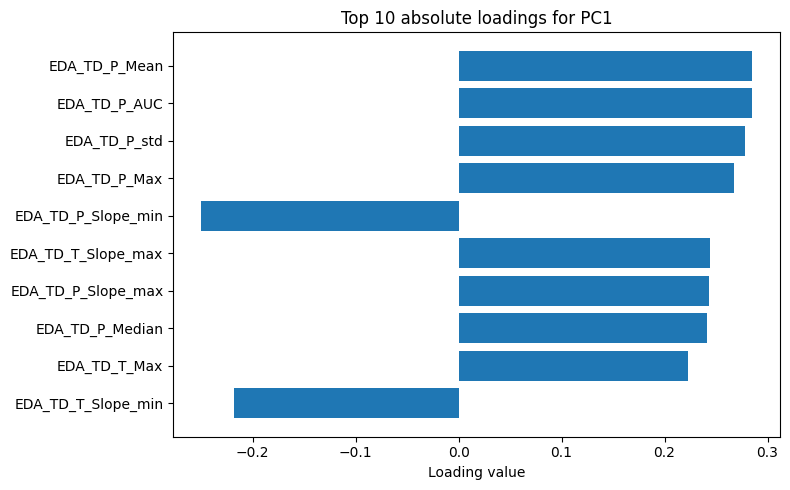

,feature,PC1_loading,PC1_abs_loading
0,EDA_TD_P_Mean,0.285335,0.285335
1,EDA_TD_P_AUC,0.285124,0.285124
2,EDA_TD_P_std,0.278144,0.278144
3,EDA_TD_P_Max,0.267340,0.267340
4,EDA_TD_P_Slope_min,-0.250549,0.250549
5,EDA_TD_T_Slope_max,0.243934,0.243934
6,EDA_TD_P_Slope_max,0.243468,0.243468
7,EDA_TD_P_Median,0.240917,0.240917
8,EDA_TD_T_Max,0.222368,0.222368
9,EDA_TD_T_Slope_min,-0.218350,0.218350


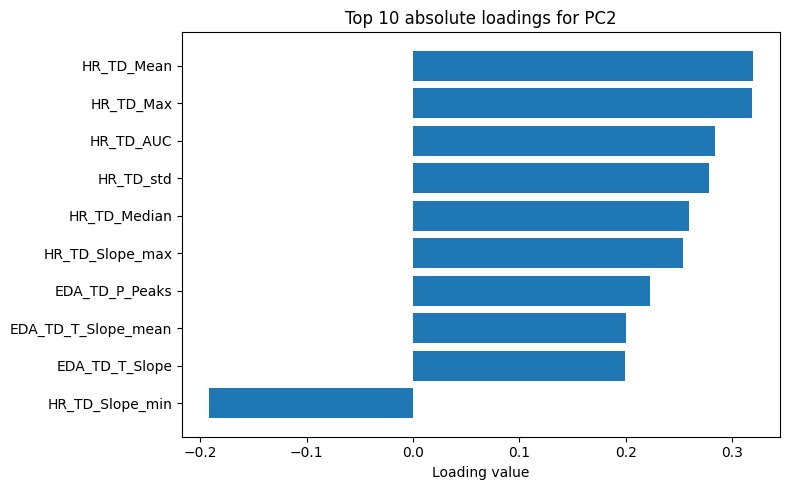

,feature,PC2_loading,PC2_abs_loading
0,HR_TD_Mean,0.319283,0.319283
1,HR_TD_Max,0.318975,0.318975
2,HR_TD_AUC,0.283307,0.283307
3,HR_TD_std,0.278119,0.278119
4,HR_TD_Median,0.259737,0.259737
5,HR_TD_Slope_max,0.253886,0.253886
6,EDA_TD_P_Peaks,0.222923,0.222923
7,EDA_TD_T_Slope_mean,0.199995,0.199995
8,EDA_TD_T_Slope,0.199370,0.199370
9,HR_TD_Slope_min,-0.191433,0.191433


In [55]:
# -------------------------
# 4) Top loadings for PC1 and PC2
# -------------------------
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=feature_names,
    columns=[f"PC{i+1}" for i in range(pca_full.components_.shape[0])]
)

top_n = 10

for pc in ["PC1", "PC2"]:
    top_load = loadings[pc].abs().sort_values(ascending=False).head(top_n)
    signed_vals = loadings.loc[top_load.index, pc]

    plt.figure(figsize=(8, 5))
    plt.barh(top_load.index[::-1], signed_vals[::-1])
    plt.xlabel("Loading value")
    plt.title(f"Top {top_n} absolute loadings for {pc}")
    plt.tight_layout()
    plt.savefig(figures_dir / f"top_loadings_{pc.lower()}.png", dpi=200)
    plt.show()

    display(pd.DataFrame({
        "feature": top_load.index,
        f"{pc}_loading": loadings.loc[top_load.index, pc].values,
        f"{pc}_abs_loading": top_load.values,
    }))




8) Top 10 absolute loadings for PC1

Result. PC1 is dominated mainly by EDA-related features, especially peak-based and tonic/phasic EDA summaries. This suggests that the first principal direction is largely capturing variation in electrodermal activity, which may reflect broad arousal-related physiological changes.

9) Top 10 absolute loadings for PC2

Result. PC2 is dominated mainly by HR-related features such as mean, max, AUC, standard deviation, and slope. This suggests that the second principal direction reflects heart-rate-related variation and provides a cardiovascular axis complementary to the EDA-dominated first component.

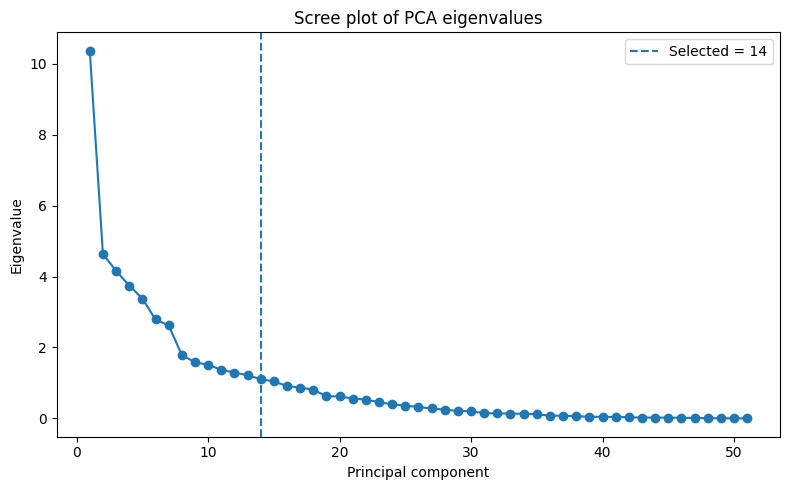

Selected PCA components at threshold 80%: 14


In [56]:
# -------------------------
# 5) Scree plot
# -------------------------
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(eigenvalues) + 1), eigenvalues, marker="o")
plt.axvline(n_components_selected, linestyle="--", label=f"Selected = {n_components_selected}")
plt.xlabel("Principal component")
plt.ylabel("Eigenvalue")
plt.title("Scree plot of PCA eigenvalues")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "pca_scree_plot.png", dpi=200)
plt.show()

print(f"Selected PCA components at threshold {config.pca_variance_threshold:.0%}: {n_components_selected}")


7) Scree plot of PCA eigenvalues

Method: Kaiser Criterion: Retain only the principal components with eigenvalues greater than 1. This means you only keep components that contribute more variance than a single original variable.

Result: The scree plot shows a steep drop in eigenvalues for the first several components, followed by a gradual flattening. This indicates that the first PCs capture most of the important structure, while later PCs contribute much smaller amounts of additional variance. By component 14, the retained eigenvalue is already close to 1, so the 14-component choice is reasonable for an 80% compression, though the plot also suggests diminishing returns after the early PCs.

In the exploratory GMM analysis with an 80% PCA variance threshold, 14 principal components were retained. Model selection by BIC favored a 2-cluster solution, indicating that the dominant latent structure in the physiological data is coarser than the 3-phase experimental design. When the model was forced to use 3 clusters, some phase alignment emerged: one cluster was more associated with phase1 and another with phase2, while the third cluster remained relatively mixed. PCA score plots showed substantial overlap between phases, which helps explain the weak phase recovery. The loading plots further suggested that PC1 was mainly driven by EDA-related features, while PC2 was mainly driven by HR-related features.

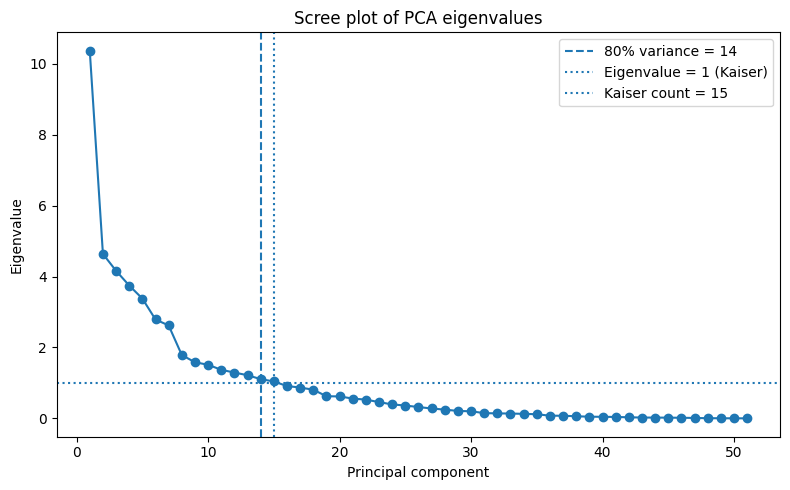

Selected PCA components at threshold 80%: 14
Components with eigenvalue > 1 (Kaiser criterion): 15


In [57]:
# -------------------------
# 5) Scree plot
# -------------------------
kaiser_k = int(np.sum(eigenvalues > 1))

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(eigenvalues) + 1), eigenvalues, marker="o")

# your current threshold-based selection
plt.axvline(
    n_components_selected,
    linestyle="--",
    label=f"80% variance = {n_components_selected}"
)

# Kaiser criterion line
plt.axhline(
    1.0,
    linestyle=":",
    label="Eigenvalue = 1 (Kaiser)"
)

# optional vertical line for number of eigenvalues > 1
plt.axvline(
    kaiser_k,
    linestyle=":",
    label=f"Kaiser count = {kaiser_k}"
)

plt.xlabel("Principal component")
plt.ylabel("Eigenvalue")
plt.title("Scree plot of PCA eigenvalues")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "pca_scree_plot.png", dpi=200)
plt.show()

print(f"Selected PCA components at threshold {config.pca_variance_threshold:.0%}: {n_components_selected}")
print(f"Components with eigenvalue > 1 (Kaiser criterion): {kaiser_k}")

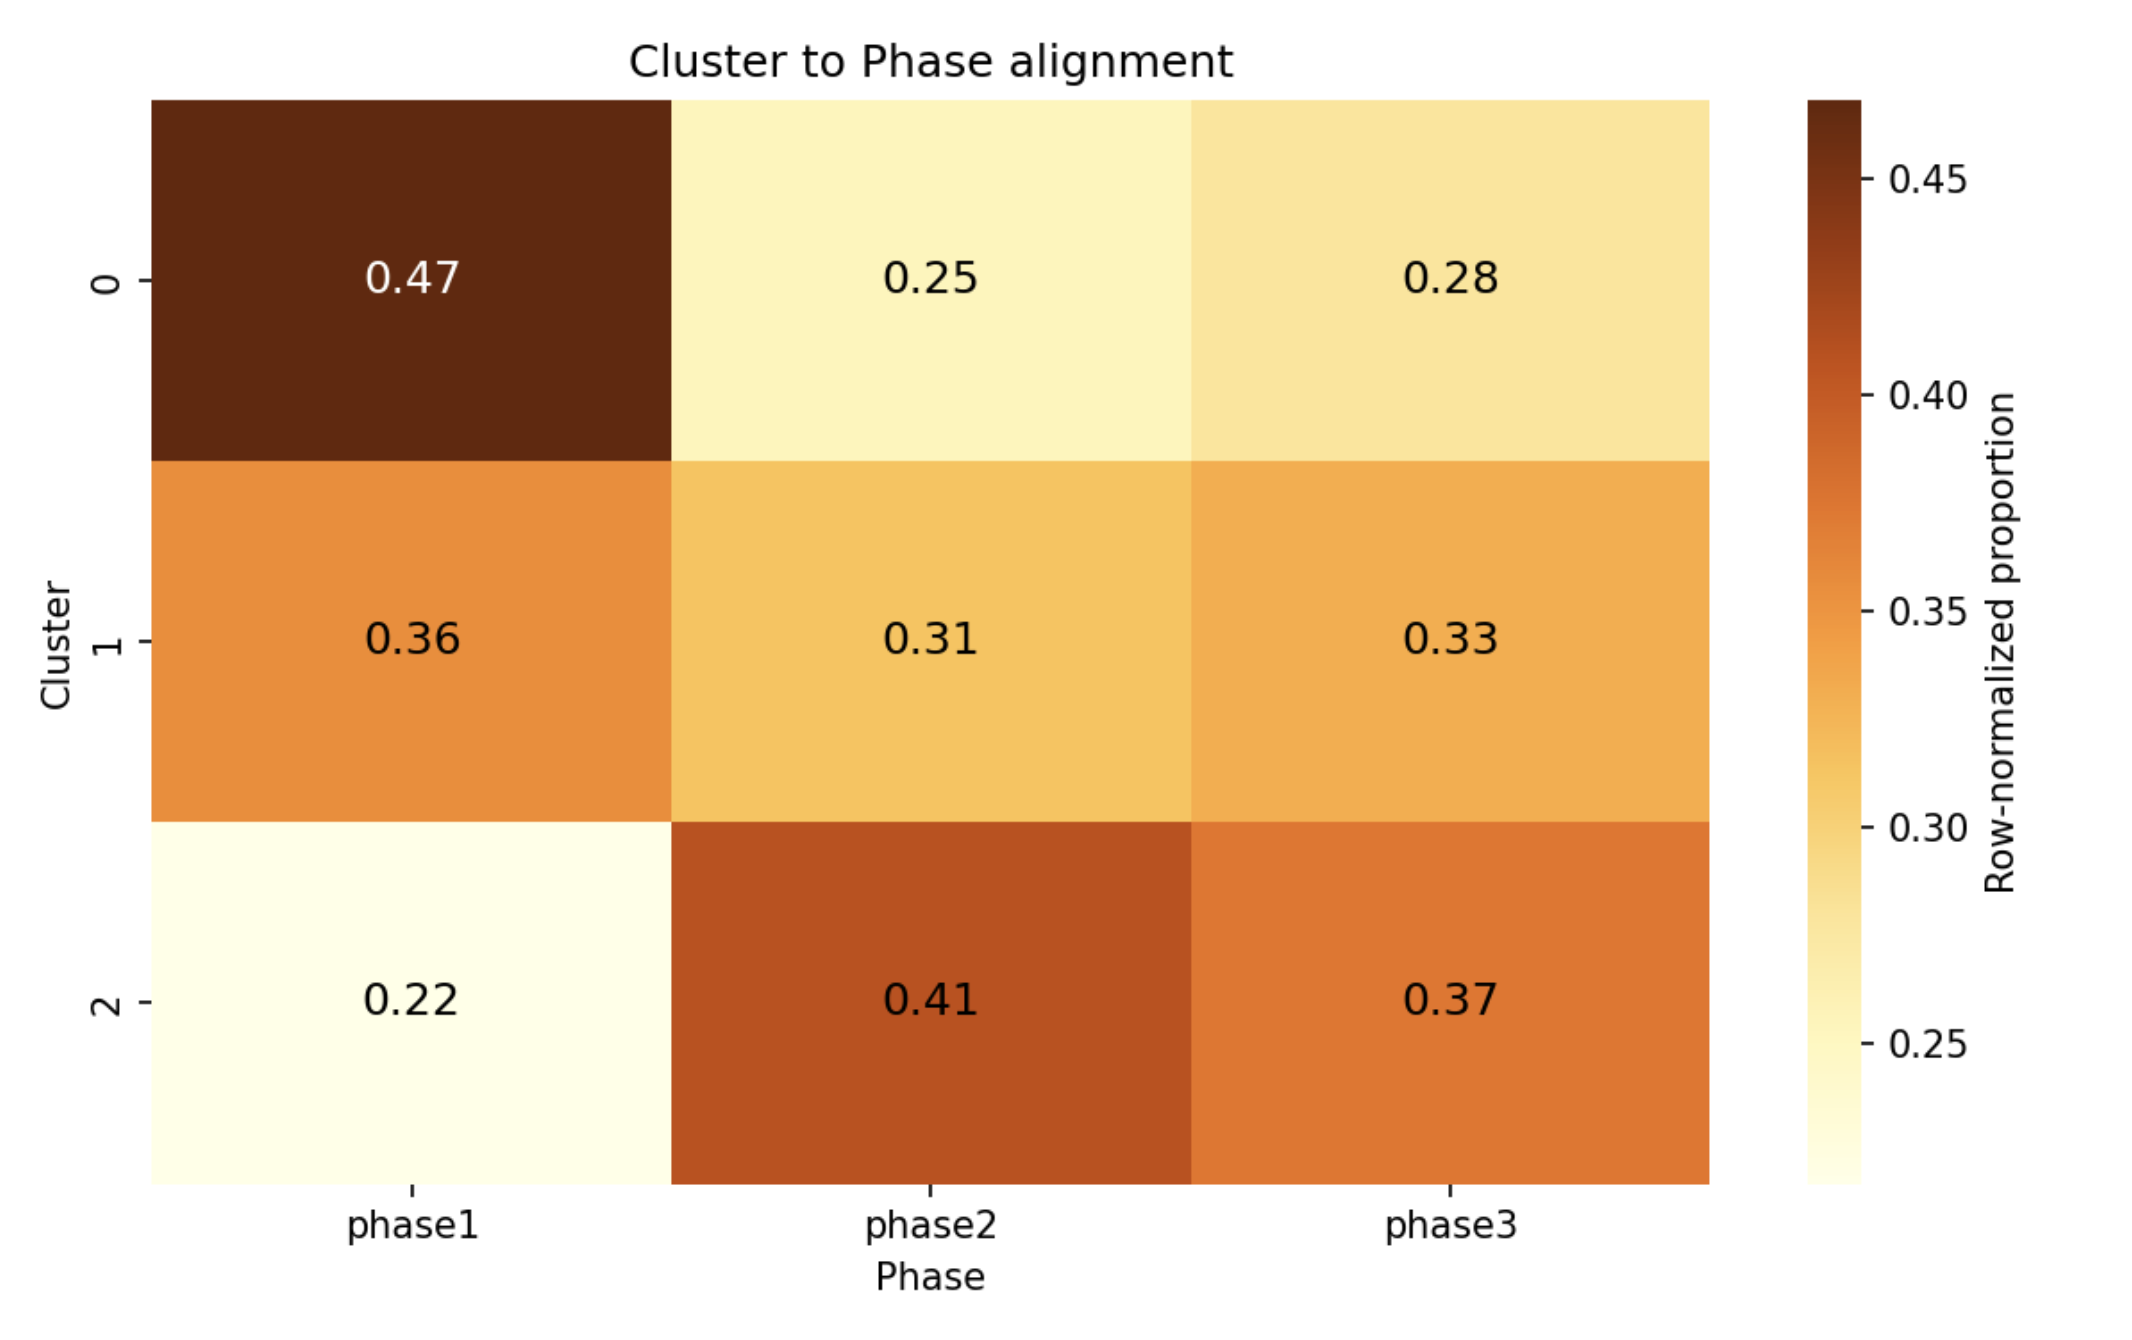

1) Cluster to Phase alignment

Result. With fixed k = 3, the clusters show only partial alignment with the three phases. Cluster 0 is most associated with phase1, cluster 2 is most associated with phase2, while cluster 1 is more mixed. This suggests that the phase structure is present in the data, but not strongly separated. The saved summary for this run also shows that this was a forced k=3 analysis, while BIC naturally preferred k=2, and the overall NMI was low at about 0.021.

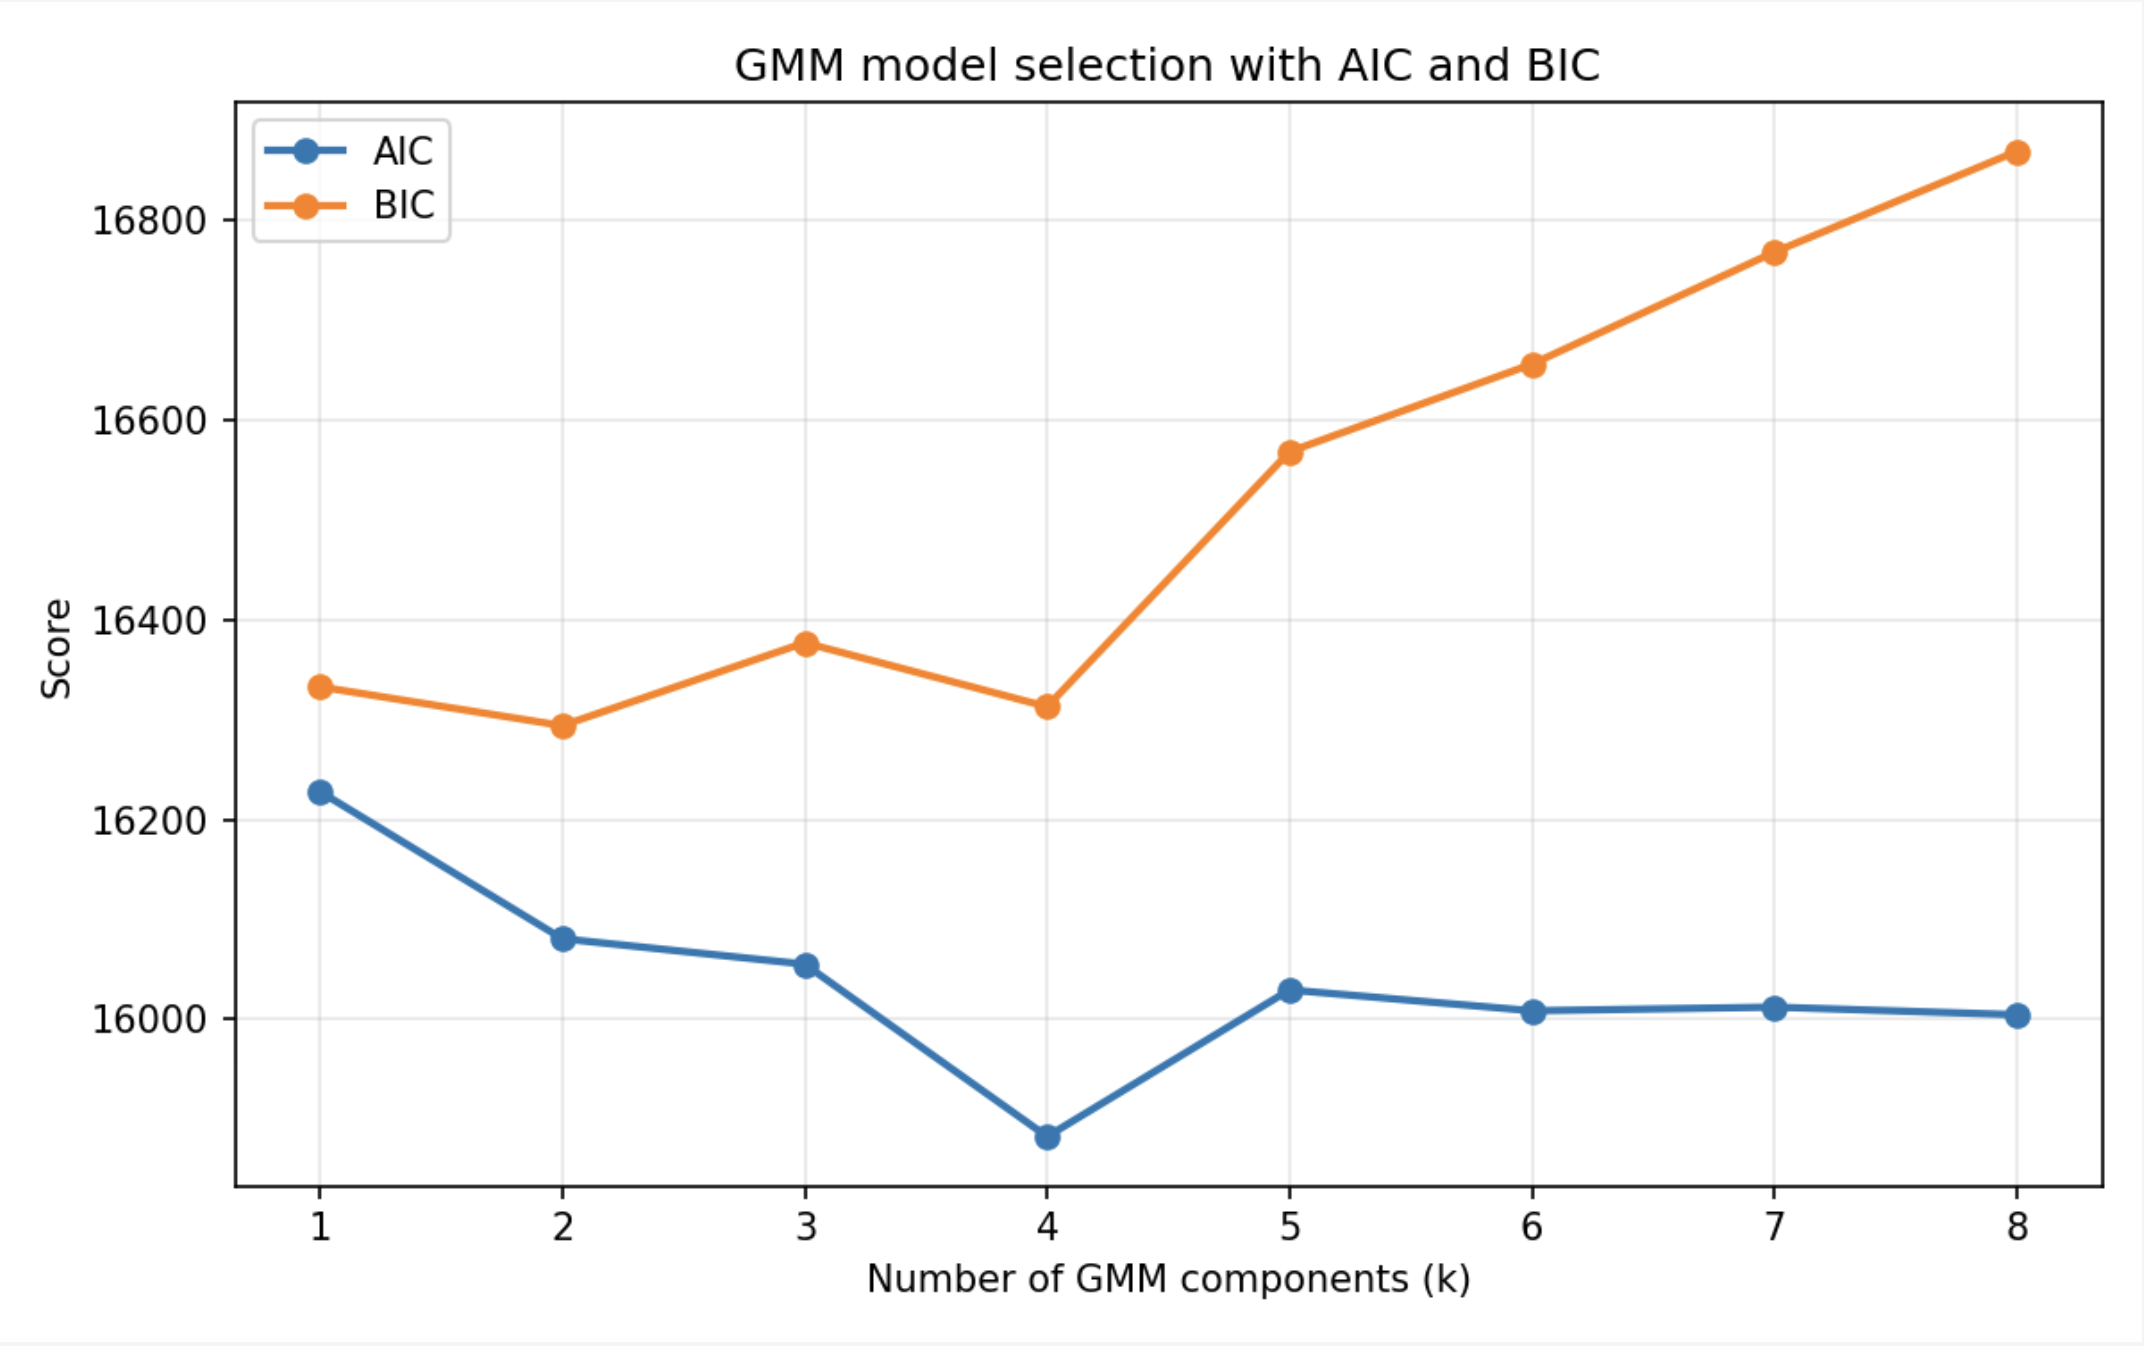

2) GMM model selection with AIC and BIC

Result. The AIC curve decreases further for larger k, while BIC reaches its minimum at k = 2. This indicates that a more complex clustering can improve fit, but after penalizing complexity, the more natural latent structure in the data is a 2-cluster solution rather than 3 clusters. This matches the saved run summary, where bic_selected_k = 2 even though the final exploratory run used k = 3.

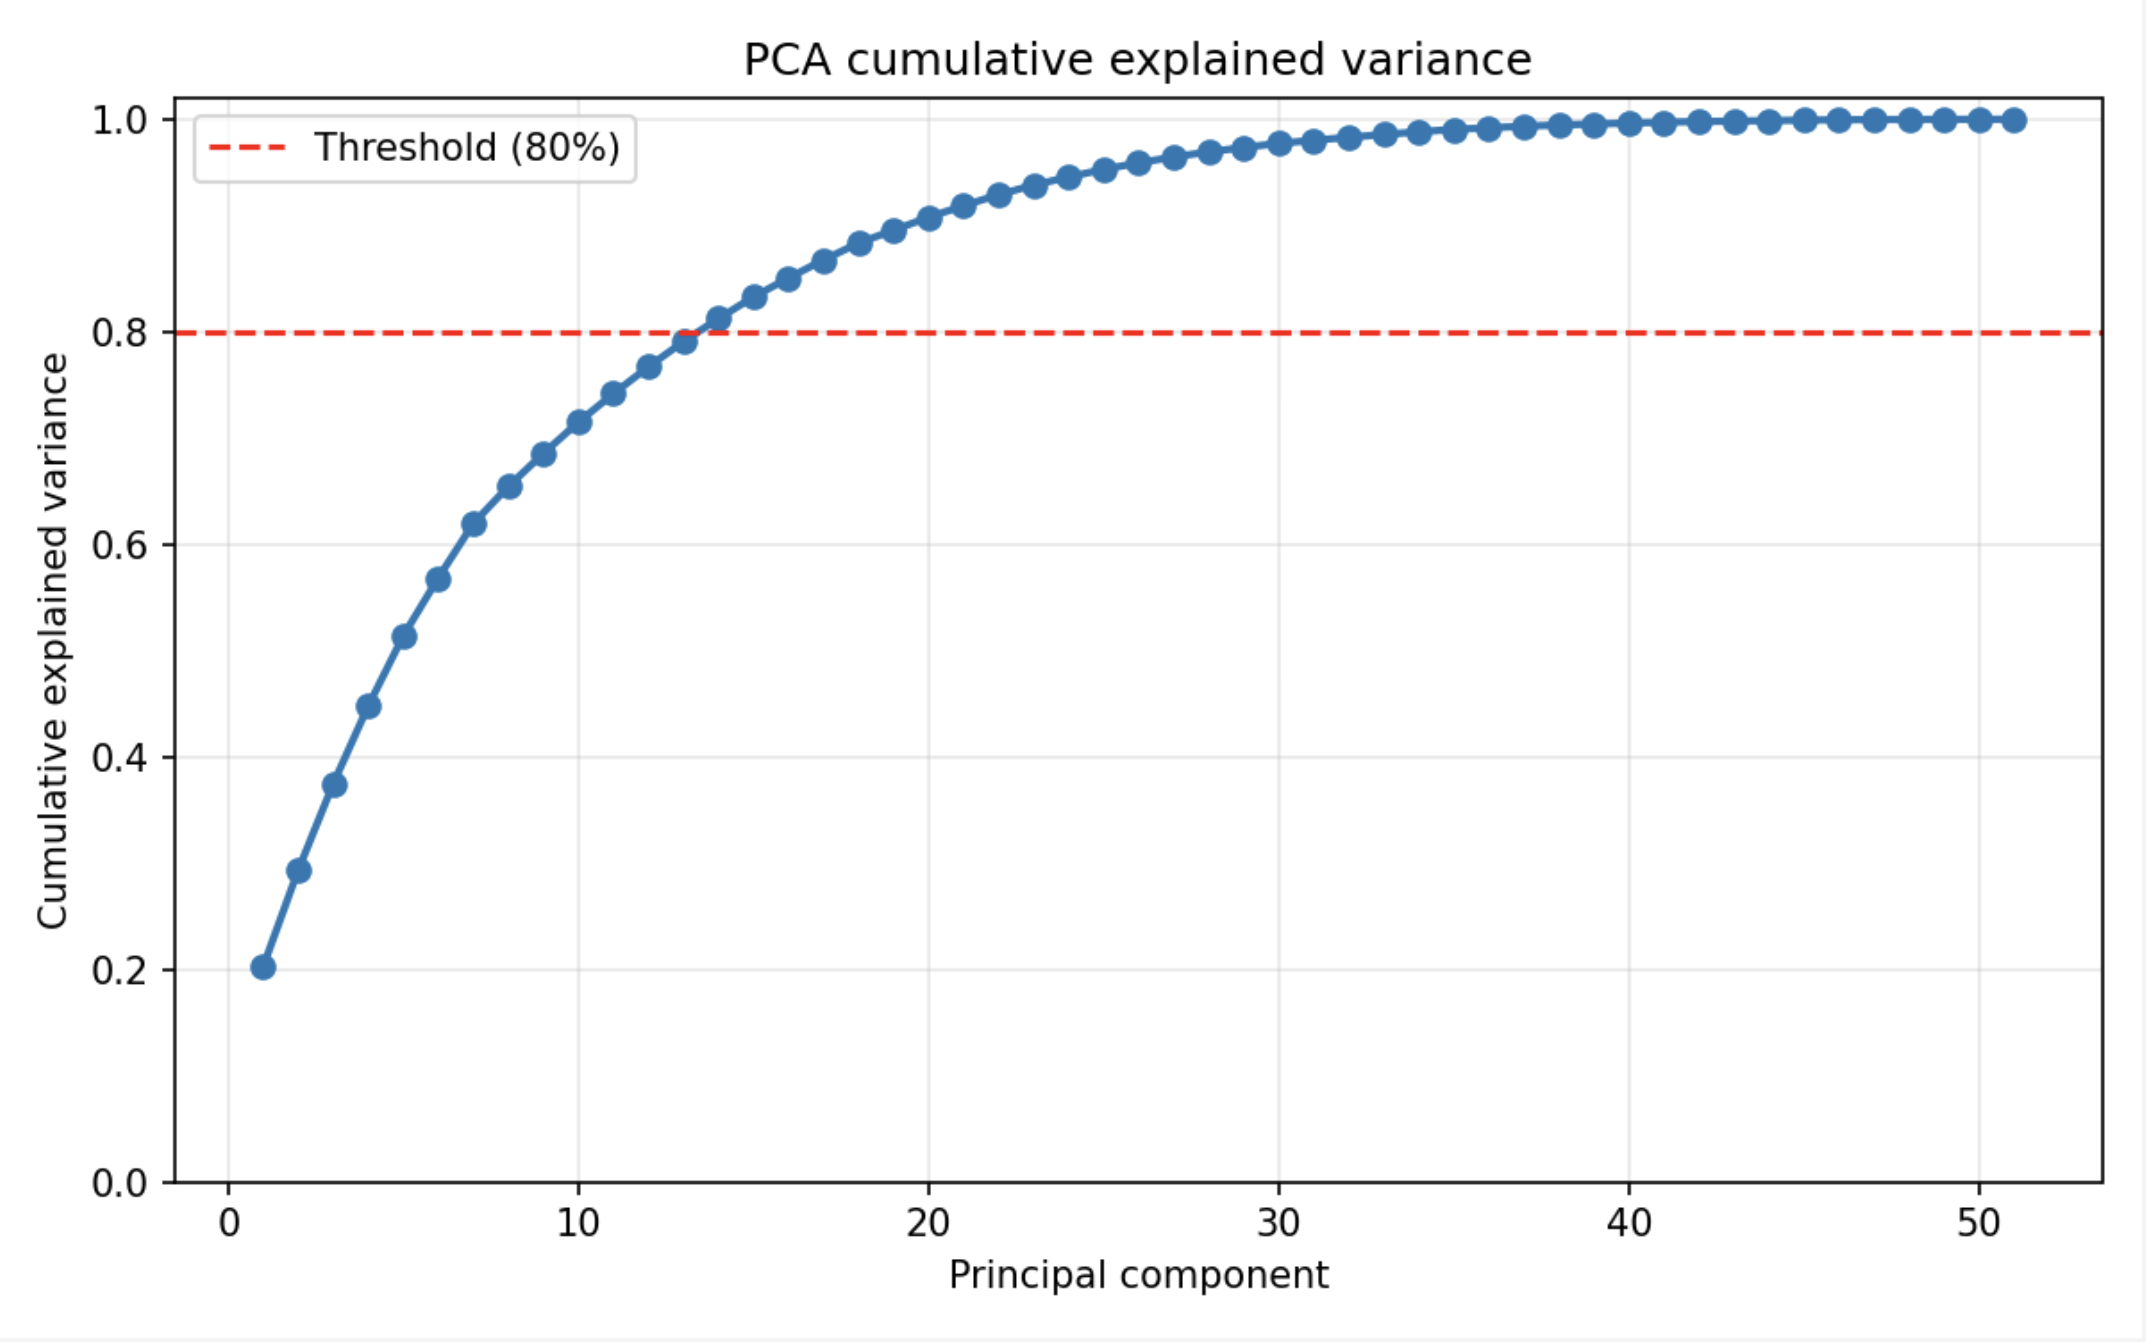

3) PCA cumulative explained variance

Result. The first principal components capture a substantial amount of the variation, and the 80% threshold is reached after 14 components. This confirms that the original 51 physiological features can be compressed into a much smaller representation before clustering, while still retaining most of the variance. The saved summary confirms selected_pca_components = 14.